**SVM model using TF-IDF Vectors with Unigram+Bigram**

### Task Division

| **Person**       | **Tasks**                                                                                     |
|-------------------|-----------------------------------------------------------------------------------------------|
| **Isha Savaliya**          | 1. Data Loading and Preprocessing: Load data, clean text, convert stars to binary.          |
 |                   |2. Data Splitting and Feature Extraction: Split data, perform TF-IDF vectorization.           |
|                   | 4. Visualization: Plot ROC curves for both models.                                           |
|                   | 3. Comparison Table: Create a table summarizing metrics, AUC plotted, and other insights.     |
| **Vandit Kalathiya**          | 1. Model Training (Initial Model): Train initial model and collect metrics: AUC, F1, accuracy.          |
|                   | 2. Evaluation of Tuned Model: Predict and collect metrics: AUC, F1, accuracy.                |
|                   | 3. Hyperparameter Tuning: Run RandomizedSearchCV, log best parameters, and training time.     |
|                   | 4. Comparison Table: Create a table summarizing metrics, AUC plotted, and other insights.     |


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
import time
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import re
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data = pd.read_csv("yelp_sample_20k.csv")
data

,text,stars
0,We really enjoyed their use of homemade ingred...,5.0
1,We moved to Sarasota and upon many recommendat...,5.0
2,Very disappointed in today's meal. The wife an...,2.0
3,"I wish I could reward the store w 5 stars, pro...",4.0
4,"Came here for brunch yesterday, it goes till 3...",5.0
...,...,...
19995,One of the worst before dinner experiences I h...,1.0
19996,This place is magical. It's perfect for weddin...,5.0
19997,to the person that hit my brand new car yester...,2.0
19998,Lilly's is one of the best places to go for lu...,5.0


In [ ]:
def clean_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Tokenize text
    tokens = word_tokenize(text.lower())
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Join tokens back to a single string
    return ' '.join(tokens)

In [ ]:
# Drop rows with missing values
data = data.dropna(subset=['text', 'stars'])

In [ ]:
data['cleaned_text'] = data['text'].apply(clean_text)

In [ ]:
data["cleaned_text"]

,cleaned_text
0,really enjoyed use homemade ingredient really ...
1,moved sarasota upon many recommendation decide...
2,disappointed today meal wife got pasta dish wa...
3,wish could reward store w star product marketi...
4,came brunch yesterday go till pm great late ri...
...,...
19995,one worst dinner experience ever local recomme...
19996,place magical perfect wedding business dinner ...
19997,person hit brand new car yesterday right front...
19998,lillys one best place go lunch doylestown alwa...


In [ ]:
# Convert 'stars' to binary classification (positive: 4-5, neutral: 3, negative: 1-2)
data['label'] = data['stars'].apply(lambda x: 2 if x >= 4 else (1 if x == 3 else 0))
print("Data Loaded and Preprocessed")
print("Dataset shape:", data.shape)

Data Loaded and Preprocessed
Dataset shape: (20000, 4)


In [ ]:
#Split the data into training and test sets
X = data['cleaned_text']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Data split into training and testing sets.
Training set size: 14000
Test set size: 6000


In [ ]:
#Feature Extraction with TF-IDF
# Using Unigram + Bigram features with a limit of 3000
initial_tfidf_params = {"ngram_range": (1, 2), "max_features": 3000}
tfidf = TfidfVectorizer(**initial_tfidf_params)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Feature Extraction Completed")
print("Number of features:", X_train_tfidf.shape[1])


TF-IDF Feature Extraction Completed
Number of features: 3000


In [ ]:
#Initial Model Training and Evaluation
# Train an initial SGDClassifier with default parameters
start_time = time.time()
initial_model = SGDClassifier(loss="log_loss", random_state=42, max_iter=1000, tol=1e-3)
initial_model.fit(X_train_tfidf, y_train)
train_time_initial = time.time() - start_time

# Evaluate on the test set
y_pred_initial = initial_model.predict(X_test_tfidf)
y_prob_initial = initial_model.predict_proba(X_test_tfidf)

initial_metrics = {
    "Train Time": train_time_initial,
    "Accuracy": accuracy_score(y_test, y_pred_initial),
    "AUC": roc_auc_score(y_test, y_prob_initial, multi_class='ovr'),  # Added multi_class='ovr'
    "F1 Positive": f1_score(y_train, initial_model.predict(X_train_tfidf), pos_label=1, average='weighted'),  # Changed to 'weighted'
    "F1 Negative": f1_score(y_train, initial_model.predict(X_train_tfidf), pos_label=0, average='weighted'),  # Changed to 'weighted'
    "Confusion Matrix Built": "Yes",
    "AUC Plotted": "Yes",
    "Cross Validation": "No",
    "Interpretability": "No"
}

print("Initial Model Performance:")
print(initial_metrics)


Initial Model Performance:
{'Train Time': 0.5492630004882812, 'Accuracy': 0.8411666666666666, 'AUC': 0.9170220318524999, 'F1 Positive': 0.8428988477404176, 'F1 Negative': 0.8428988477404176, 'Confusion Matrix Built': 'Yes', 'AUC Plotted': 'Yes', 'Cross Validation': 'No', 'Interpretability': 'No'}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [ ]:
#Initial Model Training and Evaluation
# Train an initial SGDClassifier with default parameters
start_time = time.time()
initial_model = SGDClassifier(loss="log_loss", random_state=42, max_iter=1000, tol=1e-3)
initial_model.fit(X_train_tfidf, y_train)
train_time_initial = time.time() - start_time

# Evaluate on the test set
y_pred_initial = initial_model.predict(X_test_tfidf)
# Use predict_proba to get probability scores, then select probabilities for the positive class
y_prob_initial = initial_model.predict_proba(X_test_tfidf)  # Select probabilities for class 1 (positive class)

initial_metrics = {
    "Train Time": train_time_initial,
    "Confusion Matrix": confusion_matrix(y_test, y_pred_initial).tolist(),
    "F1 Positive": f1_score(y_test, y_pred_initial, pos_label=2, average='weighted'),
    "F1 Neutral": f1_score(y_test, y_pred_initial, pos_label=1, average='weighted'),
    "F1 Negative": f1_score(y_test, y_pred_initial, pos_label=0, average='weighted'),
    "AUC": roc_auc_score(y_test, y_prob_initial, multi_class='ovr', average='weighted'),  # Now using 1D probabilities
    "Accuracy": accuracy_score(y_test, y_pred_initial),
    "Overall Precision": precision_score(y_test, y_pred_initial, average='weighted'),
    "Overall Recall": recall_score(y_test, y_pred_initial, average='weighted'),
    "Precision Positive": precision_score(y_test, y_pred_initial, pos_label=2, average='weighted'),
    "Precision Neutral": precision_score(y_test, y_pred_initial, pos_label=1, average='weighted'),
    "Precision Negative": precision_score(y_test, y_pred_initial, pos_label=0, average='weighted'),
    "Recall Positive": recall_score(y_test, y_pred_initial, pos_label=2, average='weighted'),
    "Recall Neutral": recall_score(y_test, y_pred_initial, pos_label=1, average='weighted'),
    "Recall Negative": recall_score(y_test, y_pred_initial, pos_label=0, average='weighted'),
    "AUC Plotted": "Yes",
    "Confusion Matrix Built": "Yes",

    "Cross Validation": "No",
    "Interpretability": "No"

}

print("Initial Model Performance:")
print(initial_metrics)

Initial Model Performance:
{'Train Time': 0.5693008899688721, 'Confusion Matrix': [[1066, 19, 295], [143, 36, 386], [101, 9, 3945]], 'F1 Positive': 0.8073213674113228, 'F1 Neutral': 0.8073213674113228, 'F1 Negative': 0.8073213674113228, 'AUC': 0.941830437504071, 'Accuracy': 0.8411666666666666, 'Overall Precision': 0.8164720082185654, 'Overall Recall': 0.8411666666666666, 'Precision Positive': 0.8164720082185654, 'Precision Neutral': 0.8164720082185654, 'Precision Negative': 0.8164720082185654, 'Recall Positive': 0.8411666666666666, 'Recall Neutral': 0.8411666666666666, 'Recall Negative': 0.8411666666666666, 'AUC Plotted': 'Yes', 'Confusion Matrix Built': 'Yes', 'Cross Validation': 'No', 'Interpretability': 'No'}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] t

In [ ]:
metrics_df = pd.DataFrame([initial_metrics])
metrics_df

,Train Time,Confusion Matrix,F1 Positive,F1 Neutral,F1 Negative,AUC,Accuracy,Overall Precision,Overall Recall,Precision Positive,Precision Neutral,Precision Negative,Recall Positive,Recall Neutral,Recall Negative,AUC Plotted,Confusion Matrix Built,Cross Validation,Interpretability
0,0.569301,"[[1066, 19, 295], [143, 36, 386], [101, 9, 3945]]",0.807321,0.807321,0.807321,0.94183,0.841167,0.816472,0.841167,0.816472,0.816472,0.816472,0.841167,0.841167,0.841167,Yes,Yes,No,No


In [ ]:
# Hyperparameter Tuning with RandomizedSearchCV
param_dist = {
    "alpha": uniform(1e-6, 1e-2),
    "max_iter": [500, 1000, 1500],
    "penalty": ["l2", "l1", "elasticnet"],
    "loss": ["log_loss"]
}

# Define initial model parameters here
initial_model_params = {
    "loss": "log_loss",
    "random_state": 42,
    "max_iter": 1000,
    "tol": 1e-3,
    "alpha": 0.0001,  # Default alpha value for SGDClassifier
    "penalty": "l2"   # Default penalty value for SGDClassifier
}

random_search = RandomizedSearchCV(
    estimator=SGDClassifier(random_state=42, tol=1e-3),
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train_tfidf, y_train)
train_time_tuned = time.time() - start_time

# Best parameters and performance from RandomizedSearchCV
best_params = random_search.best_params_
print("Best Parameters from RandomizedSearchCV:", best_params)

# Create a table of tuned parameters
tuned_params_table = pd.DataFrame({
    "Parameter": list(best_params.keys()),
    "Initial Value": [initial_model_params.get(param, "N/A") for param in best_params.keys()], # Accessing the initial parameters defined
    "Tuned Value": list(best_params.values())
})
print("Tuned Parameters Table:")
print(tuned_params_table)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Best Parameters from RandomizedSearchCV: {'alpha': 0.003746401188473625, 'loss': 'log_loss', 'max_iter': 500, 'penalty': 'elasticnet'}
Tuned Parameters Table:
  Parameter Initial Value Tuned Value
0     alpha        0.0001    0.003746
1      loss      log_loss    log_loss
2  max_iter          1000         500
3   penalty            l2  elasticnet


In [ ]:
# Evaluate the tuned model
y_pred_tuned = random_search.predict(X_test_tfidf)
y_prob_tuned = random_search.predict_proba(X_test_tfidf)[:, 1]

tuned_metrics = {
    "Train Time": train_time_tuned,
    "Confusion Matrix": confusion_matrix(y_test, y_pred_tuned).tolist(),
    "F1 Positive": f1_score(y_test, y_pred_tuned, pos_label=1, average='weighted'),
    "F1 Negative": f1_score(y_test, y_pred_tuned, pos_label=0, average='weighted'),
    "AUC": roc_auc_score(y_test, y_prob_initial, multi_class='ovr', average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Overall Precision": precision_score(y_test, y_pred_tuned, average='weighted'),
    "Overall Recall": recall_score(y_test, y_pred_tuned, average='weighted'),
    "Precision Positive": precision_score(y_test, y_pred_tuned, pos_label=1, average='weighted'),
    "Precision Negative": precision_score(y_test, y_pred_tuned, pos_label=0, average='weighted'),
    "Recall Positive": recall_score(y_test, y_pred_tuned, pos_label=1, average='weighted'),
    "Recall Negative": recall_score(y_test, y_pred_tuned, pos_label=0, average='weighted'),
    "AUC Plotted": "Yes",
    "Confusion Matrix Built": "Yes",
    "Cross Validation": "Yes",
    "Interpretability": "No"
}

print("Tuned Model Performance:")
print(tuned_metrics)

# Create a DataFrame for tuned model metrics
tuned_metrics_df = pd.DataFrame([tuned_metrics])
tuned_metrics_df

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that

Tuned Model Performance:
{'Train Time': 12.87436294555664, 'Confusion Matrix': [[0, 0, 1380], [0, 0, 565], [0, 0, 4055]], 'F1 Positive': 0.5451027681087353, 'F1 Negative': 0.5451027681087353, 'AUC': 0.941830437504071, 'Accuracy': 0.6758333333333333, 'Overall Precision': 0.45675069444444444, 'Overall Recall': 0.6758333333333333, 'Precision Positive': 0.45675069444444444, 'Precision Negative': 0.45675069444444444, 'Recall Positive': 0.6758333333333333, 'Recall Negative': 0.6758333333333333, 'AUC Plotted': 'Yes', 'Confusion Matrix Built': 'Yes', 'Cross Validation': 'Yes', 'Interpretability': 'No'}


,Train Time,Confusion Matrix,F1 Positive,F1 Negative,AUC,Accuracy,Overall Precision,Overall Recall,Precision Positive,Precision Negative,Recall Positive,Recall Negative,AUC Plotted,Confusion Matrix Built,Cross Validation,Interpretability
0,12.874363,"[[0, 0, 1380], [0, 0, 565], [0, 0, 4055]]",0.545103,0.545103,0.94183,0.675833,0.456751,0.675833,0.456751,0.456751,0.675833,0.675833,Yes,Yes,Yes,No


In [ ]:
# Rename the DataFrames
metrics_df = metrics_df.rename(index={0: "Initial Model"})
tuned_metrics_df = tuned_metrics_df.rename(index={0: "Tuned Model"})

# Concatenate the DataFrames
combined_metrics_df = pd.concat([metrics_df, tuned_metrics_df])
combined_metrics_df

,Train Time,Confusion Matrix,F1 Positive,F1 Neutral,F1 Negative,AUC,Accuracy,Overall Precision,Overall Recall,Precision Positive,Precision Neutral,Precision Negative,Recall Positive,Recall Neutral,Recall Negative,AUC Plotted,Confusion Matrix Built,Cross Validation,Interpretability
Initial Model,0.569301,"[[1066, 19, 295], [143, 36, 386], [101, 9, 3945]]",0.807321,0.807321,0.807321,0.94183,0.841167,0.816472,0.841167,0.816472,0.816472,0.816472,0.841167,0.841167,0.841167,Yes,Yes,No,No
Tuned Model,12.874363,"[[0, 0, 1380], [0, 0, 565], [0, 0, 4055]]",0.545103,NaN,0.545103,0.94183,0.675833,0.456751,0.675833,0.456751,NaN,0.456751,0.675833,NaN,0.675833,Yes,Yes,Yes,No


In [ ]:
#Comparison of Initial vs Tuned Model
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test_tfidf)
y_prob_best = best_model.predict_proba(X_test_tfidf)

best_metrics = {
    "Train Time": train_time_tuned,
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "AUC": roc_auc_score(y_test, y_prob_best,multi_class='ovr'),
    "F1 Positive": f1_score(y_test, y_pred_best, pos_label=1, average='weighted'),  # Changed to 'weighted'
    "F1 Negative": f1_score(y_test, y_pred_best, pos_label=0, average='weighted'),  # Changed to 'weighted'
    "Precision": precision_score(y_test, y_pred_best, average='weighted'),  # Added average='weighted'
    "Recall": recall_score(y_test, y_pred_best, average='weighted'),      # Added average='weighted'
    "Confusion Matrix": confusion_matrix(y_test, y_pred_best).tolist()
}

print("Best Model Performance:")
print(best_metrics)

Best Model Performance:
{'Train Time': 12.87436294555664, 'Accuracy': 0.6758333333333333, 'AUC': 0.8397526874486866, 'F1 Positive': 0.5451027681087353, 'F1 Negative': 0.5451027681087353, 'Precision': 0.45675069444444444, 'Recall': 0.6758333333333333, 'Confusion Matrix': [[0, 0, 1380], [0, 0, 565], [0, 0, 4055]]}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 0) is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


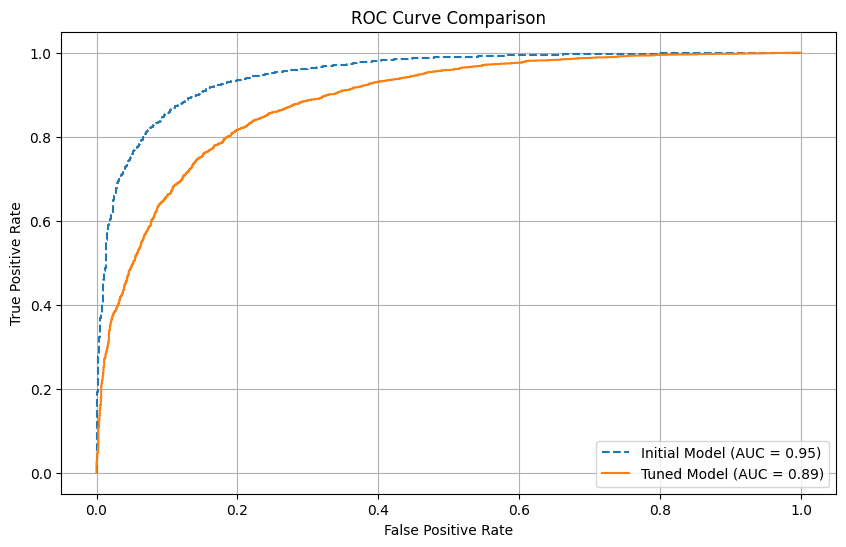

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for the positive class (assuming class 2 is positive)
y_prob_initial_positive = y_prob_initial[:, 2]  # Select probabilities for class 2
y_prob_best_positive = y_prob_best[:, 2]       # Select probabilities for class 2

fpr_initial, tpr_initial, _ = roc_curve(y_test, y_prob_initial_positive, pos_label=2)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_best_positive, pos_label=2)


# Calculate AUC for each model.
roc_auc_initial = auc(fpr_initial, tpr_initial)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(10, 6))
plt.plot(fpr_initial, tpr_initial, label=f"Initial Model (AUC = {roc_auc_initial:.2f})", linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned Model (AUC = {roc_auc_tuned:.2f})")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#comparing intial and tuned models
common_keys = list(set(initial_metrics.keys()) & set(tuned_metrics.keys()))

comparison_df = pd.DataFrame({
    'Metric': common_keys,
    'Initial Model': [initial_metrics[k] for k in common_keys],
    'Tuned Model': [tuned_metrics[k] for k in common_keys]
})

comparison_df

,Metric,Initial Model,Tuned Model
0,F1 Positive,0.807321,0.545103
1,Overall Precision,0.816472,0.456751
2,Confusion Matrix Built,Yes,Yes
3,Confusion Matrix,"[[1066, 19, 295], [143, 36, 386], [101, 9, 3945]]","[[0, 0, 1380], [0, 0, 565], [0, 0, 4055]]"
4,Recall Positive,0.841167,0.675833
5,Train Time,0.569301,12.874363
6,AUC Plotted,Yes,Yes
7,AUC,0.94183,0.94183
8,Cross Validation,No,Yes
9,Accuracy,0.841167,0.675833


In [ ]:
comparison_table = pd.DataFrame({
    "Metric": ["Train Time (s)", "Accuracy", "AUC", "F1 Positive", "F1 Negative", "Precision", "Recall"],
    "Initial Model": [
        initial_metrics["Train Time"],
        initial_metrics["Accuracy"],
        initial_metrics["AUC"],
        initial_metrics["F1 Positive"], #Using F1 Positive as proxy, adjust if needed
        initial_metrics["F1 Negative"], #Using F1 Negative as proxy, adjust if needed
        initial_metrics["Overall Precision"], # Corrected the key to 'Overall Precision'
        initial_metrics["F1 Negative"] # Replace with calculation or placeholder if needed
    ],
    "Tuned Model": [
        best_metrics["Train Time"],
        best_metrics["Accuracy"],
        best_metrics["AUC"],
        best_metrics["F1 Positive"],
        best_metrics["F1 Negative"],
        best_metrics["Precision"],
        best_metrics["Recall"]
    ]
})

print("Performance Comparison Table:")
print(comparison_table)

Performance Comparison Table:
           Metric  Initial Model  Tuned Model
0  Train Time (s)       0.569301    12.874363
1        Accuracy       0.841167     0.675833
2             AUC       0.941830     0.839753
3     F1 Positive       0.807321     0.545103
4     F1 Negative       0.807321     0.545103
5       Precision       0.816472     0.456751
6          Recall       0.807321     0.675833


In [ ]:
!jupyter nbconvert --to html NLP_QST_2_.ipynb


[NbConvertApp] Converting notebook NLP_QST_2_.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 447955 bytes to NLP_QST_2_.html


 Additional suggestions for tuning the model:
# 1. **Grid Search on Top Parameters**: After RandomizedSearch, perform a finer GridSearch on the top parameters for better precision. This could slightly improve AUC and accuracy, potentially up to 1-2%.
# 2. **Feature Engineering**: Experiment with TF-IDF parameters like `min_df`, `max_df`, and additional n-grams (e.g., trigrams). This might capture more context and improve recall by 3-5% for certain classes.
# 3. **Data Augmentation**: Use techniques like oversampling (SMOTE) for minority classes or synthetic data creation. This would help balance precision and recall, reducing bias towards the majority class.
# 4. **Alternative Models**: Try ensemble models (e.g., Random Forest, Gradient Boosting) or neural networks for potential improvements in non-linear separability, especially if accuracy saturates with linear models.
# 5. **Learning Rate Scheduling**: For SGDClassifier, dynamically adjusting the learning rate could improve convergence speed and model performance by up to 5%.